Dataset Shape: (5000, 12)
   Age_Days  Employed_Days  Credit_Amount  Loan_Annuity  Child_Count  \
0     14570           5637          64016          3419            1   
1      8160           1116         337166         16312            2   
2     12690           2567         282034          4495            2   
3     20718           3499          77938         18140            4   
4     12491            492         224750         11716            3   

   Score_Source Client_Gender  Car_Owned  House_Own Client_Education  \
0      0.263960        Female          1          1         Graduate   
1      0.502830          Male          0          1        Secondary   
2      0.359112          Male          0          0         Graduate   
3      0.377958        Female          0          1    Post Graduate   
4      0.552867          Male          1          1        Secondary   

   Client_Income  Default  
0          26428        1  
1          17647        1  
2          78079        

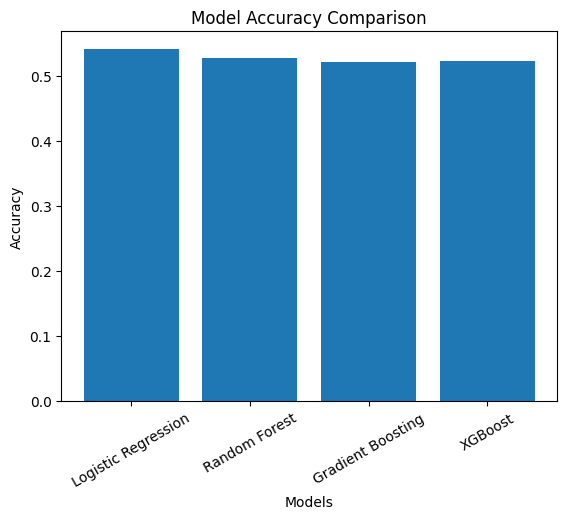


Running SHAP...


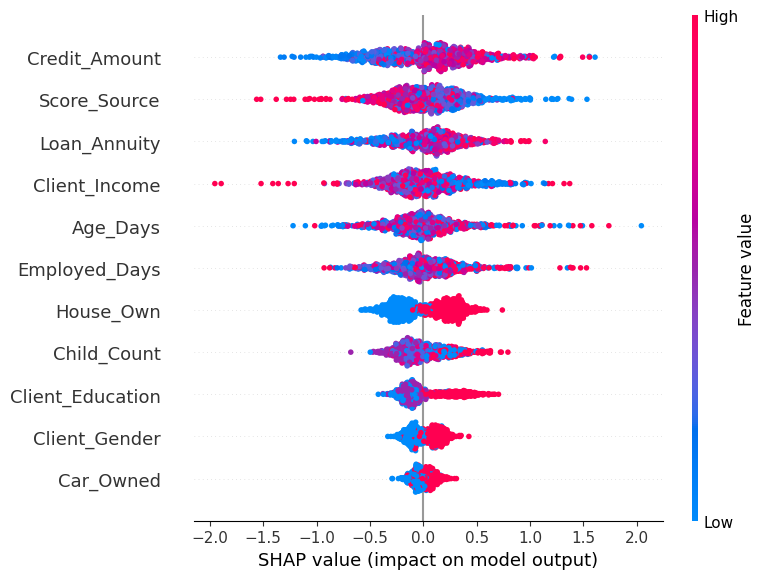

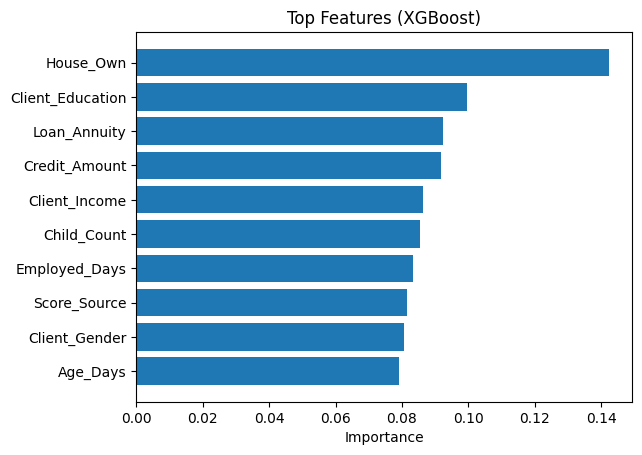


Model saved successfully!


In [4]:
# ============================================
# AUTO LOAN DEFAULT PREDICTION (FINAL CODE)
# Dataset: loan_default_dataset.csv
# ============================================

# Install if needed:
# !pip install pandas numpy scikit-learn imbalanced-learn xgboost shap matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import shap
import warnings
warnings.filterwarnings("ignore")

# ============================================
# 1. LOAD DATA
# ============================================

df = pd.read_csv("loan_default_dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# Target column
TARGET = "Default"

# ============================================
# 2. ENCODE CATEGORICAL VARIABLES
# ============================================

cat_cols = ["Client_Gender", "Client_Education"]

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# ============================================
# 3. SPLIT DATA
# ============================================

X = df.drop(TARGET, axis=1)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ============================================
# 4. HANDLE IMBALANCE (SMOTE)
# ============================================

print("\nBefore SMOTE:", np.bincount(y_train))

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train_sm))

# ============================================
# 5. FEATURE SCALING (ONLY FOR LOGISTIC)
# ============================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 6. DEFINE MODELS
# ============================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

# ============================================
# 7. TRAIN & EVALUATE
# ============================================

for name, model in models.items():
    print("\n==============================")
    print("MODEL:", name)
    print("==============================")

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train_sm)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train_sm, y_train_sm)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ============================================
# 8. MODEL COMPARISON GRAPH
# ============================================

plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

# ============================================
# 9. SHAP ANALYSIS (XGBOOST)
# ============================================

print("\nRunning SHAP...")

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_sm, y_train_sm)

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

# ============================================
# 10. FEATURE IMPORTANCE
# ============================================

importances = xgb_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top Features (XGBoost)")
plt.xlabel("Importance")
plt.show()

# ============================================
# 11. SAVE MODEL
# ============================================

import pickle

with open("final_xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("\nModel saved successfully!")